In [74]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
path = '/content/drive/MyDrive/AI Maadi 90/ML 19 1/project 2 /googleplaystore.csv'

In [77]:
df = pd.read_csv(path)

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [79]:
df.sample(10)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
1701,ROBLOX,GAME,4.5,4447346,67M,"100,000,000+",Free,0,Everyone 10+,Adventure;Action & Adventure,"July 31, 2018",2.347.225742,4.1 and up
3859,ÖBB Scotty,MAPS_AND_NAVIGATION,4.2,12572,24M,"1,000,000+",Free,0,Everyone,Maps & Navigation,"February 19, 2018",5.4 (30),4.0 and up
8603,DN Prasad,FINANCE,NaN,0,5.9M,100+,Free,0,Everyone,Finance,"April 30, 2018",1.1.2,4.0.3 and up
9284,EF Summits,TRAVEL_AND_LOCAL,NaN,0,19M,100+,Free,0,Everyone,Travel & Local,"May 20, 2018",1.1.3,4.4 and up
3595,Kids Craft Ideas,PARENTING,4.1,99,6.6M,"10,000+",Free,0,Everyone,Parenting,"March 29, 2018",1.1,4.1 and up
8812,DS cloud,TOOLS,3.2,4908,38M,"500,000+",Free,0,Everyone,Tools,"May 23, 2018",2.8.0,4.0 and up
3238,Motorola Assist,TOOLS,4.1,37333,Varies with device,"50,000,000+",Free,0,Everyone,Tools,"January 17, 2016",Varies with device,Varies with device
10276,"FirstCry Baby & Kids Shopping, Fashion & Paren...",SHOPPING,4.1,41074,16M,"5,000,000+",Free,0,Everyone,Shopping,"June 27, 2018",68,4.1 and up
8201,Sound Meter,TOOLS,4.7,88993,1.5M,"10,000,000+",Free,0,Everyone,Tools,"June 10, 2018",3.2.6,2.3 and up
1054,Nedbank Money,FINANCE,4.2,6076,32M,"500,000+",Free,0,Everyone,Finance,"July 28, 2018",4.1.1-0-prod,4.2 and up


In [80]:
df.duplicated().sum()

np.int64(483)

In [81]:
df = df.drop_duplicates()

In [82]:
df.isna().sum()

,0
App,0
Category,0
Rating,1465
Reviews,0
Size,0
Installs,0
Type,1
Price,0
Content Rating,1
Genres,0


In [83]:
df['Rating'] = pd.to_numeric(df['Rating'], errors='coerce')

# تنظيف Installs وتحويلها لرقم
df['Installs'] = (
    df['Installs']
    .str.replace(',', '', regex=False)
    .str.replace('+', '', regex=False)
)
df['Installs'] = pd.to_numeric(df['Installs'], errors='coerce')

# تحويل Reviews لرقم
df['Reviews'] = pd.to_numeric(df['Reviews'], errors='coerce')

# تقسيم Installs و Reviews لفئات (bins)
df['installs_bin'] = pd.qcut(df['Installs'], 5, duplicates='drop')
df['reviews_bin'] = pd.qcut(df['Reviews'], 5, duplicates='drop')

# حساب المود لكل مجموعة
mode_table = (
    df.groupby(['installs_bin', 'reviews_bin'])['Rating']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
)

# دالة تعويض القيم الناقصة
def fill_rating(row):
    if pd.isna(row['Rating']):
        return mode_table.get((row['installs_bin'], row['reviews_bin']), np.nan)
    return row['Rating']

# تطبيق التعويض
df['Rating'] = df.apply(fill_rating, axis=1)

# حذف الأعمدة المؤقتة
df.drop(columns=['installs_bin', 'reviews_bin'], inplace=True)

print("تم تعويض القيم الناقصة في Rating بنجاح ✅")

/tmp/ipykernel_173/3427535420.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['installs_bin', 'reviews_bin'])['Rating']


تم تعويض القيم الناقصة في Rating بنجاح ✅


In [84]:
df = df.dropna()

In [85]:
df.isna().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,0
Price,0
Content Rating,0
Genres,0


In [86]:
value_counts = df['Current Ver'].value_counts()

In [87]:
value_counts

,count
Current Ver,
Varies with device,1296
1.0,802
1.1,259
1.2,177
2.0,149
...,...
1.0.612928,1
0.3.4,1
3.36,1


In [88]:
cols = ['Reviews',  'Installs', 'Price']

for col in cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [89]:
df['Size'] = df['Size'].astype(str)

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10338 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10338 non-null  object 
 1   Category        10338 non-null  object 
 2   Rating          10338 non-null  float64
 3   Reviews         10338 non-null  float64
 4   Size            10338 non-null  object 
 5   Installs        10338 non-null  float64
 6   Type            10338 non-null  object 
 7   Price           9576 non-null   float64
 8   Content Rating  10338 non-null  object 
 9   Genres          10338 non-null  object 
 10  Last Updated    10338 non-null  object 
 11  Current Ver     10338 non-null  object 
 12  Android Ver     10338 non-null  object 
dtypes: float64(4), object(9)
memory usage: 1.1+ MB


In [91]:
df.isna().sum()

,0
App,0
Category,0
Rating,0
Reviews,0
Size,0
Installs,0
Type,0
Price,762
Content Rating,0
Genres,0


In [92]:
(df['Size'].str.contains('Varies with device', na=False).sum() / len(df)) * 100

np.float64(14.703037337976399)

In [93]:
(df['Current Ver'].str.contains('Varies with device', na=False).sum() / len(df)) * 100

np.float64(12.53627394080093)

In [94]:
size_mode = df.loc[~df['Size'].str.contains('Varies with device', na=False), 'Size'].mode()[0]
df['Size'] = df['Size'].replace('Varies with device', size_mode)

In [95]:
version_mode = df.loc[~df['Current Ver'].str.contains('Varies with device', na=False), 'Current Ver'].mode()[0]
df['Current Ver'] = df['Current Ver'].replace('Varies with device', version_mode)

In [96]:
new_size = []

for size in df['Size']:
    if 'M' in size:
        new_size.append(float(size.replace('M', '')))
    elif 'K' in size:
        new_size.append(float(size.replace('K', '')) / 1000)
    else:
        new_size.append(None)

df['Size'] = new_size

In [97]:
df['Size'] = pd.to_numeric(df['Size'])


In [98]:
price_mode = df['Price'].mode()[0]
df['Price'] = df['Price'].fillna(price_mode)
df['Price'].isna().sum()

np.int64(0)

In [99]:
import re

def convert_version(ver):
    try:
        # نلاقي أول رقم في النص
        match = re.search(r'\d+', str(ver))
        if match:
            return int(match.group())
        else:
            return 0
    except:
        return 0

df['Current Ver'] = df['Current Ver'].apply(convert_version)

In [100]:
def convert_android(ver):
    try:
        return float(str(ver).split()[0])
    except:
        return 0
df['Android Ver'] = df['Android Ver'].apply(convert_android)

In [101]:
df['Last Updated'] = pd.to_datetime(df['Last Updated'], errors='coerce')


df['Last_Day'] = df['Last Updated'].dt.day
df['Last_Weekday'] = df['Last Updated'].dt.weekday  # 0 = Monday, 6 = Sunday
df['Last_Week'] = df['Last Updated'].dt.isocalendar().week
df['Last_Month'] = df['Last Updated'].dt.month
df['Last_Year'] = df['Last Updated'].dt.year

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10338 entries, 0 to 10840
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   App             10338 non-null  object        
 1   Category        10338 non-null  object        
 2   Rating          10338 non-null  float64       
 3   Reviews         10338 non-null  float64       
 4   Size            10027 non-null  float64       
 5   Installs        10338 non-null  float64       
 6   Type            10338 non-null  object        
 7   Price           10338 non-null  float64       
 8   Content Rating  10338 non-null  object        
 9   Genres          10338 non-null  object        
 10  Last Updated    10338 non-null  datetime64[ns]
 11  Current Ver     10338 non-null  int64         
 12  Android Ver     10338 non-null  float64       
 13  Last_Day        10338 non-null  int32         
 14  Last_Weekday    10338 non-null  int32         
 15  Last_We

In [103]:
df = df.drop('App', axis=1)

In [104]:
categorical_columns_list = df.select_dtypes(include='object').columns.tolist()[1:]
categorical_columns_list

['Type', 'Content Rating', 'Genres']

In [105]:
for i in categorical_columns_list:
  print(df[i].value_counts())

Type
Free    9576
Paid     762
Name: count, dtype: int64
Content Rating
Everyone           8364
Teen               1146
Mature 17+          447
Everyone 10+        376
Adults only 18+       3
Unrated               2
Name: count, dtype: int64
Genres
Tools                       839
Entertainment               587
Education                   526
Business                    426
Medical                     408
                           ... 
Role Playing;Brain Games      1
Strategy;Education            1
Racing;Pretend Play           1
Communication;Creativity      1
Strategy;Creativity           1
Name: count, Length: 119, dtype: int64


In [106]:
df.corr(numeric_only=True , method='pearson')

,Rating,Reviews,Size,Installs,Price,Current Ver,Android Ver,Last_Day,Last_Weekday,Last_Week,Last_Month,Last_Year
Rating,1.000000,0.032254,-0.007861,0.011815,NaN,0.012037,-0.010909,0.002935,0.037139,0.001814,0.002242,0.092924
Reviews,0.032254,1.000000,0.099098,0.634980,NaN,-0.001806,-0.075037,-0.024694,-0.006718,0.041884,0.044615,0.075801
Size,-0.007861,0.099098,1.000000,0.037694,NaN,-0.004012,0.125012,-0.002987,-0.035334,0.021786,0.021682,0.139434
Installs,0.011815,0.634980,0.037694,1.000000,NaN,-0.002099,-0.106349,-0.043579,-0.024651,0.049226,0.053775,0.087447
Price,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Current Ver,0.012037,-0.001806,-0.004012,-0.002099,NaN,1.000000,0.016841,0.001333,-0.002767,-0.004830,-0.004995,0.006099
Android Ver,-0.010909,-0.075037,0.125012,-0.106349,NaN,0.016841,1.000000,0.024631,0.003741,-0.019592,-0.022478,0.111942
Last_Day,0.002935,-0.024694,-0.002987,-0.043579,NaN,0.001333,0.024631,1.000000,-0.096587,0.045232,-0.073939,-0.015895
Last_Weekday,0.037139,-0.006718,-0.035334,-0.024651,NaN,-0.002767,0.003741,-0.096587,1.000000,-0.042074,-0.009822,-0.039572
Last_Week,0.001814,0.041884,0.021786,0.049226,NaN,-0.004830,-0.019592,0.045232,-0.042074,1.000000,0.989523,-0.194430


In [107]:
numeric_columns_list = df.select_dtypes(include='number').columns.tolist()
numeric_columns_list

['Rating',
 'Reviews',
 'Size',
 'Installs',
 'Price',
 'Current Ver',
 'Android Ver',
 'Last_Day',
 'Last_Weekday',
 'Last_Week',
 'Last_Month',
 'Last_Year']

In [108]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import joblib

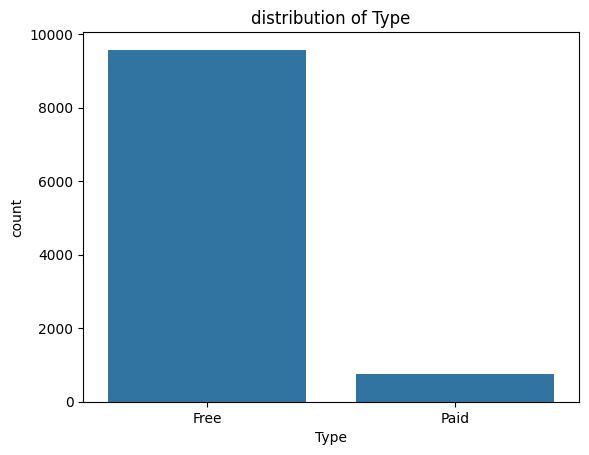

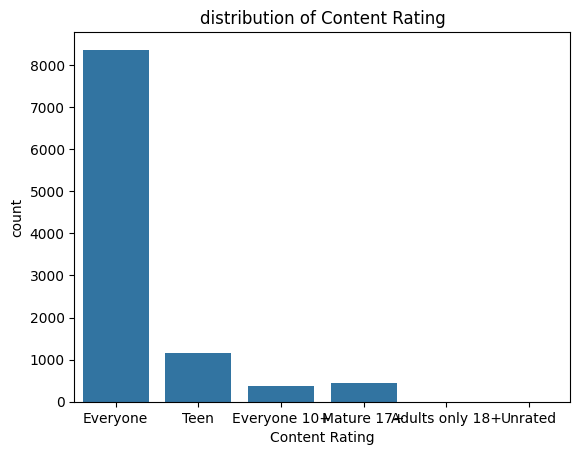

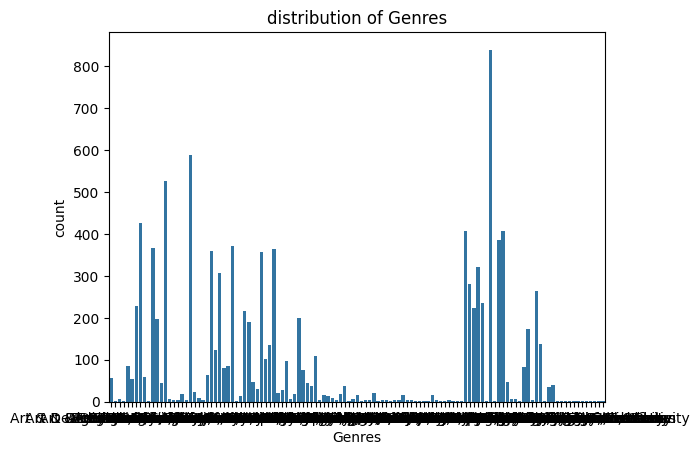

In [109]:
for i in categorical_columns_list:
  plt.figure()
  sns.countplot(x=df[i])
  plt.title(f'distribution of {i}')
  plt.show()

In [110]:
x = df.drop('Installs', axis=1)
y = df['Installs']

In [111]:
x_train , x_test , y_train , y_test = train_test_split(x , y , test_size=0.2 , random_state = 42 )

In [112]:
numeric_columns_list = x.select_dtypes(include=['int64' , 'float64']).columns.tolist()
categorical_columns_list = x.select_dtypes(include='object').columns.tolist()

In [113]:
numeric_transformer = Pipeline(steps=[
    ('imputer' , SimpleImputer(strategy='median')),
    ('scaler' , StandardScaler())
])

In [114]:
categorical_transformer = Pipeline(steps=[
    ('imputer' , SimpleImputer(strategy='most_frequent')),
    ('onehot' , OneHotEncoder(handle_unknown='ignore'))
])

In [115]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num' , numeric_transformer , numeric_columns_list),
        ('cat' , categorical_transformer , categorical_columns_list)
    ])

In [116]:
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['Rating', 'Reviews', 'Size', 'Price',
                                  'Current Ver', 'Android Ver']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Category', 'Type', 'Content Rating',
                                  'Genres'])])

In [117]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from xgboost import XGBRegressor
import numpy as np

In [132]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=10,
        random_state=42
    ))
])

xgb_pipeline.fit(x_train, y_train)

xgb_pred = xgb_pipeline.predict(x_test)

print("XGBoost Results")
print("MAE:", mean_absolute_error(y_test, xgb_pred))
print("MSE:", mean_squared_error(y_test, xgb_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))
print("R2:", r2_score(y_test, xgb_pred))

XGBoost Results
MAE: 3353963.150271034
MSE: 486418515736496.94
RMSE: 22054897.772070877
R2: 0.9359544862401411


In [134]:
import joblib

In [135]:

joblib.dump(xgb_pipeline, "best_model.joblib")

print("Model saved as best_model.joblib")

Model saved as best_model.joblib


In [136]:
loaded_model = joblib.load("best_model.joblib")


predictions = loaded_model.predict(x_test)